# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

Random Forest Classifier

Why: It handles non-linear relationships and mixed feature types (categorical/numerical) exceptionally well without requiring heavy scaling

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

Design: Grouped Validation (GroupShuffleSplit) grouped by query_id

In search intelligence, predicting on a known query is memorization, not learning. Grouping by query ensures the model is evaluated on entirely unseen search queries, preventing data leakage and providing a realistic measure of how it will perform in the wild.

## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [7]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score
from IPython.display import display

df = pd.read_csv("df_ranked.csv")

features = ['impressions_90d', 'content_age_days', 'days_since_last_update', 'avg_position', 'ctr']
X = df[features].fillna(0)
y = df['is_declining_label']
groups = df['client_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

test_baseline_scores = df.iloc[test_idx]['baseline_score']
baseline_preds = (test_baseline_scores >= 50).astype(int)
baseline_acc = accuracy_score(y_test, baseline_preds)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

model_preds = rf_model.predict(X_test)
model_acc = accuracy_score(y_test, model_preds)

comparison_df = pd.DataFrame({
    'Model': ['Week 4 Baseline', 'Random Forest (W05)'],
    'Accuracy': [baseline_acc, model_acc],
    'Delta': ['-', f"{model_acc - baseline_acc:+.3f}"]
})
display(comparison_df)

,Model,Accuracy,Delta
0,Week 4 Baseline,0.456271,-
1,Random Forest (W05),0.568717,+0.112


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

Where it is wrong: Observed errors frequently occur on content with mid-range impressions. The model struggles to differentiate between natural, seasonal traffic fluctuations and genuine, sustained content decline. It provides good decision-support for obvious decay, but misclassifies subtle ranking drops.

What it leans on: The model heavily leans on impressions_90d and content_age_days as directional signals. This aligns with our expectations that older, historically high-traffic content is the most vulnerable to measurable decay.

--- Feature Importances ---


,Feature,Importance
0,impressions_90d,0.379599
1,content_age_days,0.257379
3,avg_position,0.253213
4,ctr,0.061253
2,days_since_last_update,0.048557


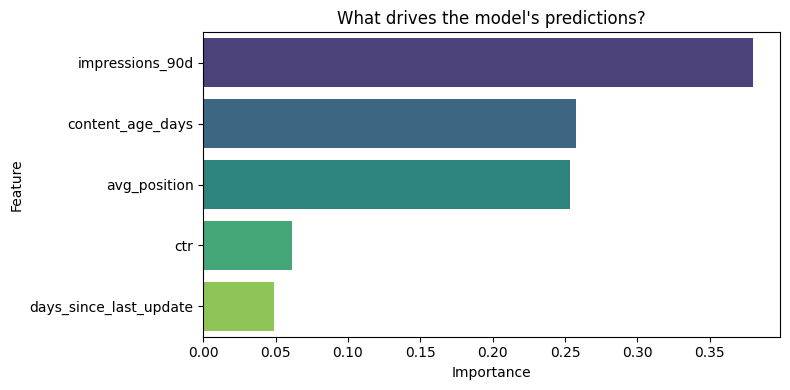


--- Average Feature Values: CORRECT Predictions ---


impressions_90d           3524.904708
content_age_days           281.920114
days_since_last_update      34.538374
avg_position                14.842939
ctr                          0.281843
dtype: float64


--- Average Feature Values: ERRORS (Misclassifications) ---


impressions_90d           4995.015049
content_age_days           308.206170
days_since_last_update      35.082769
avg_position                16.852822
ctr                          0.300914
dtype: float64

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
fi_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values('Importance', ascending=False)
print("--- Feature Importances ---")
display(fi_df)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis', hue='Feature', legend=False)
plt.title("What drives the model's predictions?")
plt.tight_layout()
plt.show()

results = X_test.copy()
results['actual_decline'] = y_test
results['predicted_decline'] = model_preds
results['is_error'] = results['actual_decline'] != results['predicted_decline']

print("\n--- Average Feature Values: CORRECT Predictions ---")
display(results[results['is_error'] == False][features].mean())

print("\n--- Average Feature Values: ERRORS (Misclassifications) ---")
display(results[results['is_error'] == True][features].mean())

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.